# 📈 Linear Regression: From Zero to Polynomial Mastery

> *A comprehensive, hands-on guide to understanding Linear Regression — mathematically, visually, and practically.*

---

## Table of Contents

1. [Simple Linear Regression](#section-1)
2. [Feature Scaling & Gradient Descent Dynamics](#section-2)
3. [Multiple Linear Regression](#section-3)
4. [Assumptions of Linear Regression](#section-4)
5. [Polynomial Regression & Overfitting](#section-5)

---

In [1]:
# ─── Global Imports & Setup ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import HTML
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['animation.embed_limit'] = 50  # MB
print('✅ All imports successful. Let\'s learn Linear Regression!')

✅ All imports successful. Let's learn Linear Regression!


<a id='section-1'></a>
---
# Section 1: Simple Linear Regression

## 1.1 The Model

Simple Linear Regression models the relationship between a single input feature $x$ and a continuous target $y$ using a straight line:

$$\hat{y} = \beta_0 + \beta_1 x$$

where:
- $\beta_0$ is the **intercept** (the value of $\hat{y}$ when $x = 0$)
- $\beta_1$ is the **slope** (how much $\hat{y}$ changes per unit increase in $x$)

---

## 1.2 The Cost Function: Mean Squared Error (MSE)

To measure how well our line fits the data, we use the **Mean Squared Error (MSE)**:

$$J(\beta_0, \beta_1) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$

The $\frac{1}{2}$ factor is a mathematical convenience that cancels out when we differentiate. The goal is to find $\beta_0$ and $\beta_1$ that **minimize** this function.

---

## 1.3 Gradient Descent Optimization

Gradient Descent is an iterative optimization algorithm. At each step, we move the parameters in the direction of the **negative gradient** of the cost function:

$$\frac{\partial J}{\partial \beta_0} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

$$\frac{\partial J}{\partial \beta_1} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)}$$

**Update rules** (simultaneously):

$$\beta_0 \leftarrow \beta_0 - \alpha \cdot \frac{\partial J}{\partial \beta_0}$$

$$\beta_1 \leftarrow \beta_1 - \alpha \cdot \frac{\partial J}{\partial \beta_1}$$

where $\alpha$ is the **learning rate** — a small positive scalar that controls the step size. Too large: diverge. Too small: converge very slowly.

In [2]:
# ─── Section 1: Simple Linear Regression — Data & Scratch Implementation ─────

# 1. Generate synthetic data: y = 2x + 1 + noise
m = 80  # number of samples
x = np.linspace(0, 10, m)
y_true_slr = 2.0 * x + 1.0 + np.random.randn(m) * 2.5

# 2. Gradient Descent from scratch
def compute_mse(b0, b1, x, y):
    """Compute MSE for given parameters."""
    y_hat = b0 + b1 * x
    return np.mean((y_hat - y) ** 2) / 2

def gradient_descent_slr(x, y, lr=0.01, n_iters=200):
    """Run gradient descent and record history."""
    b0, b1 = 0.0, 0.0
    m = len(y)
    history = {'b0': [b0], 'b1': [b1], 'cost': [compute_mse(b0, b1, x, y)]}
    for _ in range(n_iters):
        y_hat = b0 + b1 * x
        err   = y_hat - y
        grad_b0 = err.mean()
        grad_b1 = (err * x).mean()
        b0 -= lr * grad_b0
        b1 -= lr * grad_b1
        history['b0'].append(b0)
        history['b1'].append(b1)
        history['cost'].append(compute_mse(b0, b1, x, y))
    return b0, b1, history

# Run gradient descent
b0_final, b1_final, hist = gradient_descent_slr(x, y_true_slr, lr=0.01, n_iters=200)
print(f'✅ Converged: β₀ = {b0_final:.4f}, β₁ = {b1_final:.4f}')
print(f'   True values:  β₀ = 1.0000, β₁ = 2.0000')
print(f'   Final MSE: {hist["cost"][-1]:.4f}')

✅ Converged: β₀ = 0.4129, β₁ = 2.0476
   True values:  β₀ = 1.0000, β₁ = 2.0000
   Final MSE: 2.8300


In [3]:
# ─── Section 1: Animation — Regression Line + Loss Contour ───────────────────
plt.style.use('dark_background')

# Build loss surface grid for contour plot
b0_grid = np.linspace(-5, 8, 120)
b1_grid = np.linspace(-1, 4, 120)
B0, B1  = np.meshgrid(b0_grid, b1_grid)
Z = np.array([[compute_mse(b0, b1, x, y_true_slr)
               for b0 in b0_grid] for b1 in b1_grid])

# Subsample history frames
n_frames   = 60
frame_idxs = np.linspace(0, len(hist['b0']) - 1, n_frames, dtype=int)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d0d')
for ax in axes:
    ax.set_facecolor('#0d0d0d')

ax_left, ax_right = axes

# ── Left: scatter + line ──
ax_left.scatter(x, y_true_slr, color='#00e5ff', s=18, alpha=0.7, label='Data', zorder=3)
line_plot, = ax_left.plot([], [], color='#ff6b35', lw=2.5, label='Regression line', zorder=4)
title_left = ax_left.set_title('', color='white', fontsize=13, pad=10)
ax_left.set_xlabel('x', color='#aaaaaa', fontsize=11)
ax_left.set_ylabel('y', color='#aaaaaa', fontsize=11)
ax_left.tick_params(colors='#888888')
ax_left.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=10)
ax_left.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax_left.set_ylim(y_true_slr.min() - 3, y_true_slr.max() + 3)

# ── Right: contour + trajectory ──
contour = ax_right.contourf(B0, B1, Z, levels=40, cmap='magma', alpha=0.85)
ax_right.contour(B0, B1, Z, levels=20, colors='#ffffff', alpha=0.15, linewidths=0.5)
traj_line, = ax_right.plot([], [], color='#00e5ff', lw=1.8, zorder=5)
traj_dot,  = ax_right.plot([], [], 'o', color='#ffffff', ms=7, zorder=6)
ax_right.plot(b0_final, b1_final, '*', color='#ffd700', ms=14,
              label='Global min', zorder=7)
ax_right.set_xlabel('β₀ (intercept)', color='#aaaaaa', fontsize=11)
ax_right.set_ylabel('β₁ (slope)', color='#aaaaaa', fontsize=11)
ax_right.set_title('Loss Landscape & GD Trajectory', color='white', fontsize=13, pad=10)
ax_right.tick_params(colors='#888888')
ax_right.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=10)
fig.colorbar(contour, ax=ax_right, label='MSE', shrink=0.8).ax.yaxis.label.set_color('white')

fig.tight_layout(pad=2.5)

def init():
    line_plot.set_data([], [])
    traj_line.set_data([], [])
    traj_dot.set_data([], [])
    return line_plot, traj_line, traj_dot

def update(frame):
    idx  = frame_idxs[frame]
    b0_i = hist['b0'][idx]
    b1_i = hist['b1'][idx]
    # Regression line
    x_plot = np.array([x.min(), x.max()])
    line_plot.set_data(x_plot, b0_i + b1_i * x_plot)
    title_left.set_text(f'Simple Linear Regression  |  Iteration {idx}  |  '
                        f'β₀={b0_i:.2f}, β₁={b1_i:.2f}')
    # Trajectory
    traj_b0 = hist['b0'][:idx + 1]
    traj_b1 = hist['b1'][:idx + 1]
    traj_line.set_data(traj_b0, traj_b1)
    traj_dot.set_data([b0_i], [b1_i])
    return line_plot, traj_line, traj_dot, title_left

anim_slr = animation.FuncAnimation(
    fig, update, frames=n_frames, init_func=init,
    interval=80, blit=False
)
plt.close(fig)
HTML(anim_slr.to_html5_video())

<a id='section-2'></a>
---
# Section 2: Feature Scaling & Gradient Descent Dynamics

## Why Does Feature Scaling Matter?

When features have very different scales (e.g., $x_1 \in [0, 1]$ vs $x_2 \in [0, 10000]$), the loss landscape becomes a long, narrow **ellipse**. Gradient Descent wastes many steps bouncing across the steep walls instead of heading directly to the minimum.

Scaling the features makes the loss landscape **spherical**, and Gradient Descent converges in far fewer iterations.

---

## Scaling Techniques

### 1. Z-score Standardization
$$x' = \frac{x - \mu}{\sigma}$$
Transforms the data to have **zero mean** and **unit variance**. Best when the data is approximately normally distributed. Preserves outliers but makes them less influential.

### 2. Min-Max Scaling
$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$
Squashes all values into the range $[0, 1]$. Very sensitive to outliers because the min and max are used. Good when the algorithm needs bounded inputs (e.g., neural networks with sigmoid activations).

### 3. Robust Scaling (IQR)
$$x' = \frac{x - Q_2}{Q_3 - Q_1}$$
Uses the **median** $Q_2$ and **interquartile range** (IQR = $Q_3 - Q_1$) instead of mean/std. Highly resistant to outliers. Recommended when your data has significant outliers that you cannot or do not want to remove.

### 4. MaxAbs Scaling
$$x' = \frac{x}{|x_{\max}|}$$
Scales each feature by its maximum absolute value. Range is $[-1, 1]$. Preserves zeros and sign of data — ideal for sparse data.

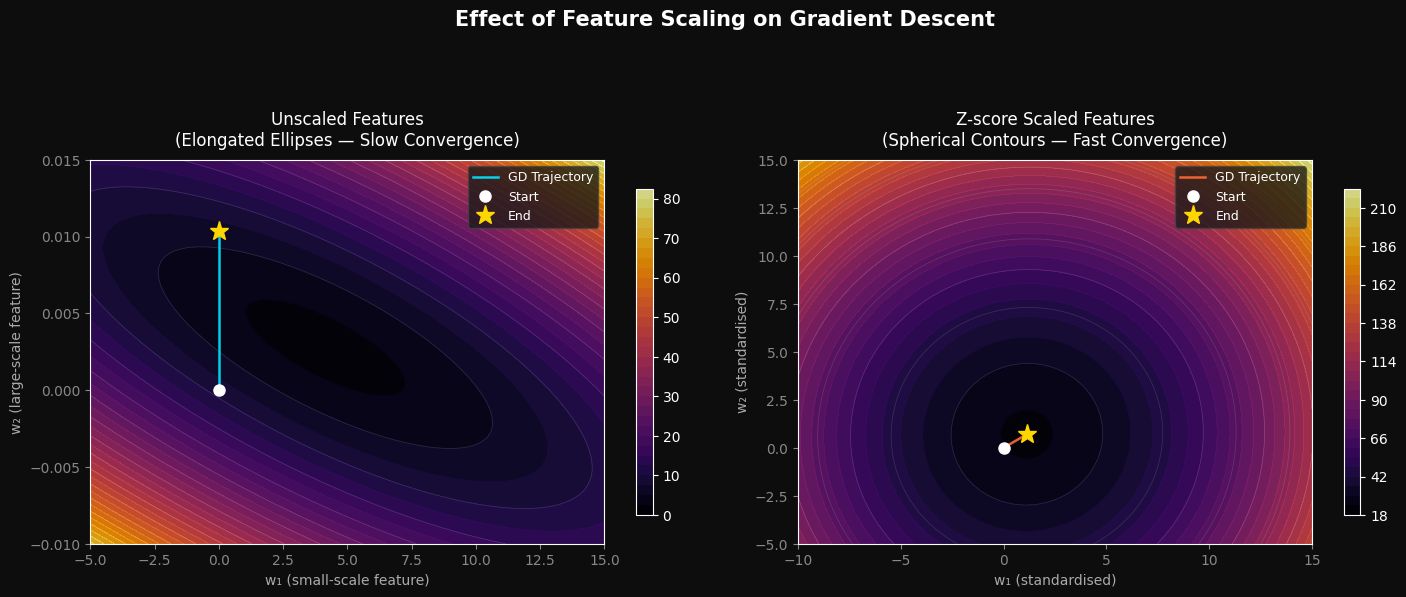

📌 Key insight: scaled features → near-circular contours → GD takes the direct path!


In [4]:
# ─── Section 2: Feature Scaling — Contour Comparison ─────────────────────────
plt.style.use('dark_background')

# Generate data with very different feature scales
n = 150
x1_raw = np.random.uniform(0, 1, n)        # small scale
x2_raw = np.random.uniform(0, 1000, n)     # large scale
true_w0, true_w1, true_w2 = 3.0, 5.0, 0.002
y_sc = true_w0 + true_w1 * x1_raw + true_w2 * x2_raw + np.random.randn(n) * 2

# ── Helper: compute loss on a 2D grid (w1, w2) for fixed w0 ──
def mse_grid_2d(X, y, w0_fixed, w_grid_1, w_grid_2, feat_idx=(0,1)):
    W1, W2 = np.meshgrid(w_grid_1, w_grid_2)
    Z = np.zeros_like(W1)
    for i, w1 in enumerate(w_grid_1):
        for j, w2 in enumerate(w_grid_2):
            y_hat = w0_fixed + w1 * X[:, feat_idx[0]] + w2 * X[:, feat_idx[1]]
            Z[j, i] = np.mean((y_hat - y) ** 2) / 2
    return W1, W2, Z

# ── Unscaled data ──
X_raw = np.stack([x1_raw, x2_raw], axis=1)
W1_r, W2_r, Z_r = mse_grid_2d(
    X_raw, y_sc, w0_fixed=3.0,
    w_grid_1=np.linspace(-5, 15, 80),
    w_grid_2=np.linspace(-0.01, 0.015, 80)
)

# ── Scaled data (Z-score) ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
W1_s, W2_s, Z_s = mse_grid_2d(
    X_scaled, y_sc, w0_fixed=0.0,
    w_grid_1=np.linspace(-10, 15, 80),
    w_grid_2=np.linspace(-5, 15, 80)
)

# ── GD trajectory on unscaled ──
def run_gd_2d(X, y, lr=0.001, n_iters=300):
    w = np.zeros(X.shape[1])
    b = 0.0
    hist_w = [w.copy()]
    for _ in range(n_iters):
        y_hat = X @ w + b
        err = y_hat - y
        grad_w = X.T @ err / len(y)
        grad_b = err.mean()
        w -= lr * grad_w
        b -= lr * grad_b
        hist_w.append(w.copy())
    return np.array(hist_w)

hist_raw    = run_gd_2d(X_raw, y_sc, lr=1e-6, n_iters=300)
hist_scaled = run_gd_2d(X_scaled, y_sc, lr=0.05, n_iters=300)

# ── Plot ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0d0d0d')

titles   = ['Unscaled Features\n(Elongated Ellipses — Slow Convergence)',
            'Z-score Scaled Features\n(Spherical Contours — Fast Convergence)']
W1_list  = [W1_r, W1_s]
W2_list  = [W2_r, W2_s]
Z_list   = [Z_r, Z_s]
hists    = [hist_raw, hist_scaled]
xlabels  = ['w₁ (small-scale feature)', 'w₁ (standardised)']
ylabels  = ['w₂ (large-scale feature)', 'w₂ (standardised)']
colors   = ['#00e5ff', '#ff6b35']

for i, ax in enumerate(axes):
    ax.set_facecolor('#0d0d0d')
    cf = ax.contourf(W1_list[i], W2_list[i], Z_list[i], levels=35,
                     cmap='inferno', alpha=0.85)
    ax.contour(W1_list[i], W2_list[i], Z_list[i], levels=15,
               colors='white', alpha=0.12, linewidths=0.6)
    traj = hists[i]
    ax.plot(traj[:, 0], traj[:, 1], '-', color=colors[i],
            lw=1.8, alpha=0.9, label='GD Trajectory')
    ax.plot(traj[0, 0], traj[0, 1], 'o', color='white', ms=8, label='Start', zorder=5)
    ax.plot(traj[-1, 0], traj[-1, 1], '*', color='#ffd700', ms=14, label='End', zorder=5)
    ax.set_title(titles[i], color='white', fontsize=12, pad=10)
    ax.set_xlabel(xlabels[i], color='#aaaaaa', fontsize=10)
    ax.set_ylabel(ylabels[i], color='#aaaaaa', fontsize=10)
    ax.tick_params(colors='#888888')
    ax.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=9)
    fig.colorbar(cf, ax=ax, shrink=0.85).ax.yaxis.label.set_color('white')

fig.suptitle('Effect of Feature Scaling on Gradient Descent',
             color='white', fontsize=15, y=1.02, fontweight='bold')
fig.tight_layout(pad=2.5)
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print('📌 Key insight: scaled features → near-circular contours → GD takes the direct path!')

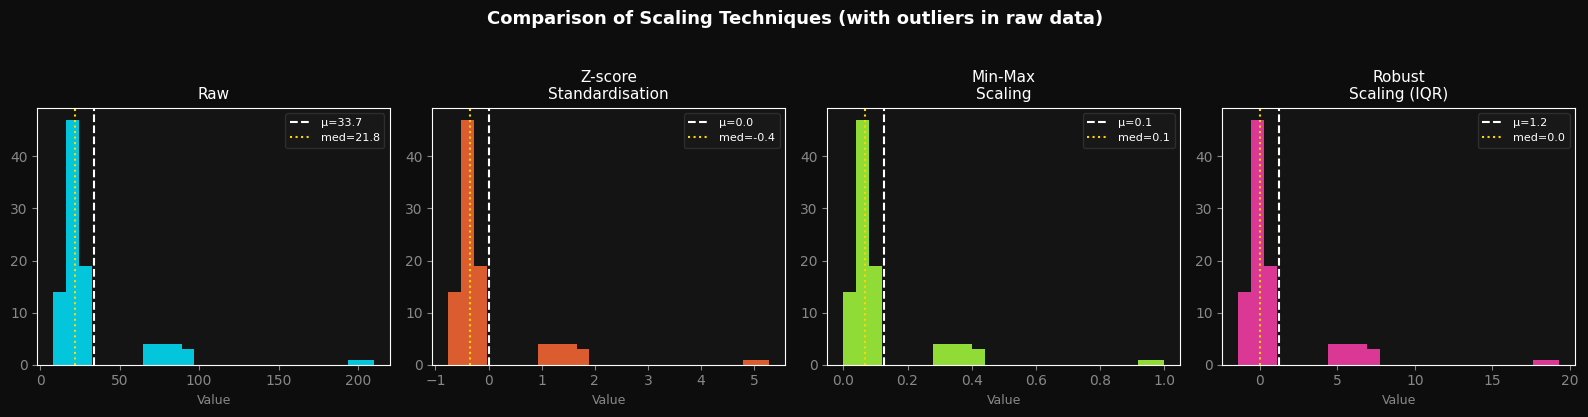

In [5]:
# ─── Section 2 (extra): Quick comparison of scaling transforms ───────────────
plt.style.use('dark_background')

rng = np.random.default_rng(0)
raw_data = np.concatenate([
    rng.normal(20, 5, 80),
    rng.normal(80, 10, 15),   # high-value cluster
    [200, 210]                 # outliers
])

d = raw_data.reshape(-1, 1)
scalers = {
    'Raw': raw_data,
    'Z-score\nStandardisation': StandardScaler().fit_transform(d).ravel(),
    'Min-Max\nScaling': MinMaxScaler().fit_transform(d).ravel(),
    'Robust\nScaling (IQR)': RobustScaler().fit_transform(d).ravel(),
}

palette = ['#00e5ff', '#ff6b35', '#a8ff3e', '#ff3eac']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.patch.set_facecolor('#0d0d0d')

for ax, (name, data), col in zip(axes, scalers.items(), palette):
    ax.set_facecolor('#141414')
    ax.hist(data, bins=25, color=col, alpha=0.85, edgecolor='none')
    ax.axvline(np.mean(data), color='white', lw=1.5, ls='--', label=f'μ={np.mean(data):.1f}')
    ax.axvline(np.median(data), color='#ffd700', lw=1.5, ls=':', label=f'med={np.median(data):.1f}')
    ax.set_title(name, color='white', fontsize=11)
    ax.tick_params(colors='#888888')
    ax.set_xlabel('Value', color='#888888', fontsize=9)
    ax.legend(facecolor='#1a1a1a', edgecolor='#333', labelcolor='white', fontsize=8)

fig.suptitle('Comparison of Scaling Techniques (with outliers in raw data)',
             color='white', fontsize=13, fontweight='bold', y=1.03)
fig.tight_layout()
plt.show()

<a id='section-3'></a>
---
# Section 3: Multiple Linear Regression

## 3.1 Extending to $n$ Features

When we have $n$ features per sample, the model becomes:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

We express this compactly using **matrix notation**. Let:
- $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ — design matrix with a leading column of ones for the bias term
- $\boldsymbol{\beta} \in \mathbb{R}^{n+1}$ — parameter vector
- $\mathbf{Y} \in \mathbb{R}^{m}$ — target vector

Then:

$$\mathbf{\hat{Y}} = \mathbf{X}\boldsymbol{\beta}$$

$$J(\boldsymbol{\beta}) = \frac{1}{2m} \| \mathbf{X}\boldsymbol{\beta} - \mathbf{Y} \|^2$$

## 3.2 Gradient Descent in Matrix Form

The gradient becomes a vector:

$$\nabla_{\boldsymbol{\beta}} J = \frac{1}{m} \mathbf{X}^T (\mathbf{X}\boldsymbol{\beta} - \mathbf{Y})$$

Update rule:

$$\boldsymbol{\beta} \leftarrow \boldsymbol{\beta} - \alpha \cdot \frac{1}{m} \mathbf{X}^T (\mathbf{X}\boldsymbol{\beta} - \mathbf{Y})$$

This single vectorized expression handles any number of features efficiently — NumPy executes this as optimized BLAS calls.

## 3.3 The Normal Equation (Closed-form Solution)

For small datasets, we can solve for $\boldsymbol{\beta}$ analytically:

$$\boldsymbol{\beta}^* = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{Y}$$

This is $\mathcal{O}(n^3)$ due to matrix inversion — practical only when $n$ is small (< few thousand features). Gradient Descent scales to millions of features and samples.

In [6]:
# ─── Section 3: Multiple Regression — 3D Animation ───────────────────────────
plt.style.use('dark_background')

# Generate 2-feature synthetic data: y = 1 + 2*x1 + 3*x2 + noise
m3 = 100
x1_m = np.random.uniform(0, 5, m3)
x2_m = np.random.uniform(0, 5, m3)
y_m  = 1.0 + 2.0 * x1_m + 3.0 * x2_m + np.random.randn(m3) * 1.5

# Design matrix with bias column
X_m  = np.stack([np.ones(m3), x1_m, x2_m], axis=1)

# Gradient Descent — vectorized
def gd_mlr(X, y, lr=0.02, n_iters=300):
    beta = np.zeros(X.shape[1])
    m    = len(y)
    betas_hist = [beta.copy()]
    costs_hist = [np.mean((X @ beta - y) ** 2) / 2]
    for _ in range(n_iters):
        err  = X @ beta - y
        grad = X.T @ err / m
        beta -= lr * grad
        betas_hist.append(beta.copy())
        costs_hist.append(np.mean((X @ beta - y) ** 2) / 2)
    return np.array(betas_hist), costs_hist

betas_hist, costs_hist = gd_mlr(X_m, y_m, lr=0.02, n_iters=300)
beta_final = betas_hist[-1]
print(f'✅ Final params: β₀={beta_final[0]:.3f}, β₁={beta_final[1]:.3f}, β₂={beta_final[2]:.3f}')
print(f'   True:        β₀=1.000, β₁=2.000, β₂=3.000')

# Closed-form for comparison
beta_ne = np.linalg.lstsq(X_m, y_m, rcond=None)[0]
print(f'   Normal eq:   β₀={beta_ne[0]:.3f}, β₁={beta_ne[1]:.3f}, β₂={beta_ne[2]:.3f}')

✅ Final params: β₀=0.643, β₁=1.893, β₂=3.161
   True:        β₀=1.000, β₁=2.000, β₂=3.000
   Normal eq:   β₀=0.481, β₁=1.919, β₂=3.191


In [8]:
# ─── Section 3: 3D Animation — Regression Plane + Loss Curve ─────────────────
plt.style.use('dark_background')

n_frames_3d = 50
frame_idxs_3d = np.linspace(0, len(betas_hist) - 1, n_frames_3d, dtype=int)

fig3d = plt.figure(figsize=(15, 6))
fig3d.patch.set_facecolor('#0d0d0d')

ax3d  = fig3d.add_subplot(121, projection='3d')
ax_lc = fig3d.add_subplot(122)

for ax in [ax3d, ax_lc]:
    ax.set_facecolor('#0d0d0d')

ax3d.set_xlabel('x₁', color='#aaaaaa', labelpad=6)
ax3d.set_ylabel('x₂', color='#aaaaaa', labelpad=6)
ax3d.set_zlabel('y', color='#aaaaaa', labelpad=6)
ax3d.tick_params(colors='#888888')
ax3d.xaxis.pane.fill = ax3d.yaxis.pane.fill = ax3d.zaxis.pane.fill = False

# Static scatter
sc = ax3d.scatter(x1_m, x2_m, y_m, c='#00e5ff', s=20, alpha=0.6, depthshade=True)

# Plane mesh
px = np.linspace(x1_m.min(), x1_m.max(), 20)
py = np.linspace(x2_m.min(), x2_m.max(), 20)
PX, PY = np.meshgrid(px, py)
plane_surf = [None]

title_3d = ax3d.set_title('', color='white', fontsize=11, pad=12)

# Loss curve
ax_lc.set_facecolor('#0d0d0d')
ax_lc.set_xlabel('Iteration', color='#aaaaaa', fontsize=11)
ax_lc.set_ylabel('MSE Loss', color='#aaaaaa', fontsize=11)
ax_lc.set_title('Loss Curve', color='white', fontsize=13, pad=10)
ax_lc.tick_params(colors='#888888')
ax_lc.set_xlim(0, len(costs_hist))
ax_lc.set_ylim(0, max(costs_hist) * 1.05)
ax_lc.plot(range(len(costs_hist)), costs_hist, color='#333333', lw=1.5, alpha=0.5)
lc_line, = ax_lc.plot([], [], color='#ff6b35', lw=2.5, label='GD Loss')
lc_dot,  = ax_lc.plot([], [], 'o', color='white', ms=8, zorder=5)
ax_lc.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=10)

fig3d.tight_layout(pad=2.5)

def init3d():
    lc_line.set_data([], [])
    lc_dot.set_data([], [])
    return lc_line, lc_dot

def update3d(frame):
    idx  = frame_idxs_3d[frame]
    b    = betas_hist[idx]
    PZ   = b[0] + b[1] * PX + b[2] * PY
    if plane_surf[0] is not None:
        plane_surf[0].remove()
    plane_surf[0] = ax3d.plot_surface(
        PX, PY, PZ, alpha=0.45, color='#ff6b35', linewidth=0,
        antialiased=True
    )
    title_3d.set_text(f'Multiple Linear Regression  |  Iter {idx}  |  '
                      f'β₀={b[0]:.2f}, β₁={b[1]:.2f}, β₂={b[2]:.2f}')
    lc_line.set_data(range(idx + 1), costs_hist[:idx + 1])
    lc_dot.set_data([idx], [costs_hist[idx]])
    return lc_line, lc_dot

anim_3d = animation.FuncAnimation(
    fig3d, update3d, frames=n_frames_3d, init_func=init3d,
    interval=100, blit=False
)
plt.close(fig3d)
HTML(anim_3d.to_html5_video())

<a id='section-4'></a>
---
# Section 4: Assumptions of Linear Regression

Linear Regression is a **parametric model**. Its statistical validity depends on several core assumptions. Violating them doesn't necessarily ruin your predictions, but it **does** invalidate hypothesis tests, confidence intervals, and coefficient interpretations.

---

## Assumption 1: Linearity

**Statement:** The relationship between the predictors $x_i$ and the expected value of the response $\mathbb{E}[y | X]$ is linear:

$$\mathbb{E}[y | X] = \mathbf{X}\boldsymbol{\beta}$$

**What can go wrong:** If the true relationship is non-linear (e.g., quadratic or exponential), the model will systematically underfit. Residuals will show a clear pattern instead of random scatter.

**Diagnosis:** Plot **Residuals vs. Fitted values**. A horizontal band of residuals around zero is ideal. Any curve or wave indicates non-linearity.

---

## Assumption 2: Independence of Errors (No Autocorrelation)

**Statement:** The errors $\epsilon^{(i)}$ are independent of each other:

$$\text{Cov}(\epsilon^{(i)}, \epsilon^{(j)}) = 0 \quad \forall i \neq j$$

**What can go wrong:** In time-series data, yesterday's error can correlate with today's (e.g., stock prices). This inflates the apparent sample size and deflates standard errors, making your t-tests over-confident.

**Diagnosis:** The **Durbin-Watson test** (statistic near 2 → no autocorrelation) or plotting residuals vs. time.

---

## Assumption 3: Homoscedasticity (Constant Variance of Residuals)

**Statement:** The variance of the errors is constant across all levels of the predictors:

$$\text{Var}(\epsilon^{(i)}) = \sigma^2 \quad \forall i$$

**What can go wrong:** If variance increases with the fitted value (a **"fan" or "trumpet" shape** in residuals), OLS estimates are still unbiased but **no longer minimum variance** — they are inefficient. Standard errors are wrong.

**Diagnosis:** **Scale-Location plot** (√|standardized residuals| vs fitted values). A flat, horizontal trend is ideal. Upward slope = heteroscedasticity.

**Fix:** Log-transform the target, use Weighted Least Squares, or use robust standard errors (HC3).

---

## Assumption 4: Normality of Residuals

**Statement:** The residuals are normally distributed:

$$\epsilon \sim \mathcal{N}(0, \sigma^2)$$

**What can go wrong:** This assumption matters primarily for **small samples** (when relying on t-tests and F-tests for inference). By the **Central Limit Theorem**, OLS coefficients are approximately normal in large samples regardless.

**Diagnosis:** **Q-Q (Quantile-Quantile) plot** — points along the diagonal line = normally distributed residuals. **Shapiro-Wilk test** for small samples.

---

## Assumption 5: No Perfect Multicollinearity

**Statement:** No predictor can be expressed as a perfect linear combination of other predictors. Mathematically, $\mathbf{X}^T\mathbf{X}$ must be invertible (full rank).

$$\text{rank}(\mathbf{X}) = n + 1$$

**What can go wrong:** Perfect multicollinearity makes the normal equation unsolvable. Near-perfect collinearity causes numerically unstable, highly variable coefficient estimates.

**Diagnosis:** **Variance Inflation Factor (VIF)**:

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

where $R^2_j$ is the R² from regressing $x_j$ on all other predictors. Rule of thumb: VIF > 10 → problematic multicollinearity.

**Fix:** Remove one of the correlated predictors, use Ridge Regression (L2 regularization), or perform PCA.

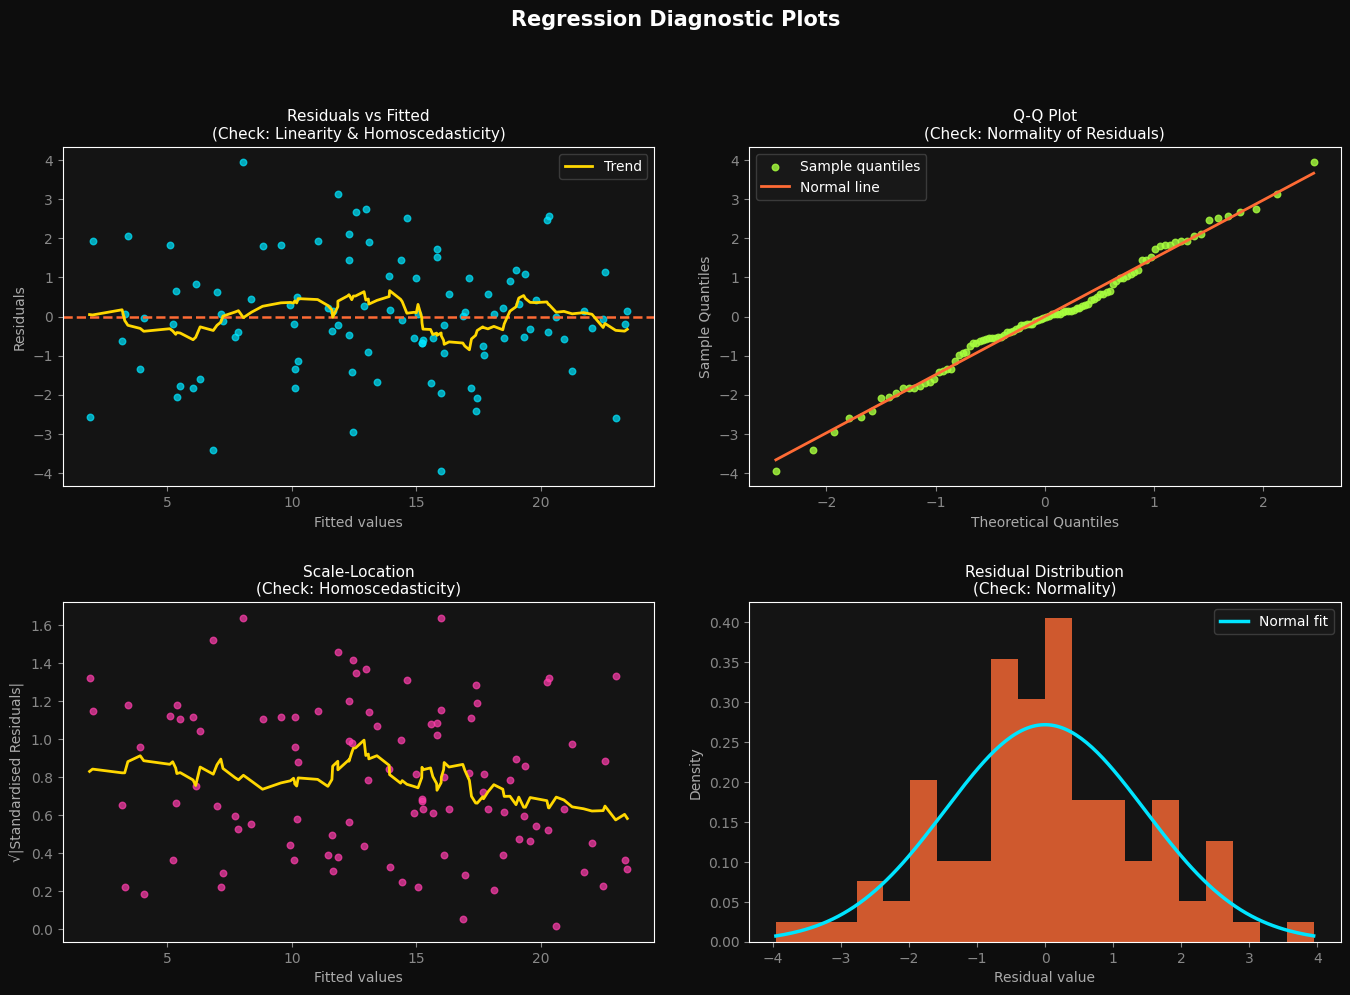

In [9]:
# ─── Section 4: Diagnostic Plots — Visualising the Assumptions ───────────────
plt.style.use('dark_background')
import scipy.stats as stats

# Fit a model and extract residuals
lr_diag = LinearRegression()
lr_diag.fit(X_m[:, 1:], y_m)   # using x1, x2 from MLR section
y_hat_diag = lr_diag.predict(X_m[:, 1:])
residuals  = y_m - y_hat_diag
std_resid  = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0d0d0d')
axes = axes.ravel()

for ax in axes:
    ax.set_facecolor('#141414')

# Plot 1: Residuals vs Fitted (Linearity + Homoscedasticity)
axes[0].scatter(y_hat_diag, residuals, color='#00e5ff', s=22, alpha=0.7)
axes[0].axhline(0, color='#ff6b35', lw=1.8, ls='--')
axes[0].set_xlabel('Fitted values', color='#aaa'); axes[0].set_ylabel('Residuals', color='#aaa')
axes[0].set_title('Residuals vs Fitted\n(Check: Linearity & Homoscedasticity)', color='white', fontsize=11)

# Add lowess-like smooth line
sorted_idx = np.argsort(y_hat_diag)
from scipy.ndimage import uniform_filter1d
smooth_res = uniform_filter1d(residuals[sorted_idx], size=15)
axes[0].plot(y_hat_diag[sorted_idx], smooth_res, color='#ffd700', lw=2, label='Trend')
axes[0].legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white')

# Plot 2: Q-Q Plot (Normality)
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[1].scatter(osm, osr, color='#a8ff3e', s=22, alpha=0.8, label='Sample quantiles')
axes[1].plot(osm, slope * np.array(osm) + intercept, color='#ff6b35', lw=2, label='Normal line')
axes[1].set_xlabel('Theoretical Quantiles', color='#aaa')
axes[1].set_ylabel('Sample Quantiles', color='#aaa')
axes[1].set_title('Q-Q Plot\n(Check: Normality of Residuals)', color='white', fontsize=11)
axes[1].legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white')

# Plot 3: Scale-Location (Homoscedasticity)
axes[2].scatter(y_hat_diag, np.sqrt(np.abs(std_resid)), color='#ff3eac', s=22, alpha=0.7)
smooth_sl = uniform_filter1d(np.sqrt(np.abs(std_resid[sorted_idx])), size=15)
axes[2].plot(y_hat_diag[sorted_idx], smooth_sl, color='#ffd700', lw=2)
axes[2].set_xlabel('Fitted values', color='#aaa')
axes[2].set_ylabel('√|Standardised Residuals|', color='#aaa')
axes[2].set_title('Scale-Location\n(Check: Homoscedasticity)', color='white', fontsize=11)

# Plot 4: Residuals histogram
axes[3].hist(residuals, bins=20, color='#ff6b35', alpha=0.8, edgecolor='none', density=True)
xn = np.linspace(residuals.min(), residuals.max(), 200)
axes[3].plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()),
             color='#00e5ff', lw=2.5, label='Normal fit')
axes[3].set_xlabel('Residual value', color='#aaa')
axes[3].set_ylabel('Density', color='#aaa')
axes[3].set_title('Residual Distribution\n(Check: Normality)', color='white', fontsize=11)
axes[3].legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white')

for ax in axes:
    ax.tick_params(colors='#888888')

fig.suptitle('Regression Diagnostic Plots', color='white', fontsize=15,
             fontweight='bold', y=1.01)
fig.tight_layout(pad=2.5)
plt.savefig('diagnostics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

<a id='section-5'></a>
---
# Section 5: Polynomial Regression & Overfitting

## 5.1 Beyond Straight Lines

Linear Regression can model **non-linear** relationships by engineering polynomial features:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

Crucially, **this is still a linear model** — it's linear in the *parameters* $\boldsymbol{\beta}$, even though it's non-linear in $x$. The trick is simply to treat $x, x^2, \ldots, x^d$ as separate features and feed them to the standard linear regression framework.

---

## 5.2 The Bias-Variance Tradeoff

The expected test error of a model can be decomposed as:

$$\mathbb{E}[(y - \hat{y})^2] = \underbrace{\text{Bias}^2[\hat{y}]}_{\text{systematic error}} + \underbrace{\text{Var}[\hat{y}]}_{\text{sensitivity to data}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

| Degree | Bias | Variance | Result |
|--------|------|----------|--------|
| 1 (line) | **High** | Low | **Underfitting** — misses the true pattern |
| 3–5 | Low | Low | ✅ **Sweet spot** — generalises well |
| 15+ | Low | **High** | **Overfitting** — memorises noise |

---

## 5.3 Regularisation as a Remedy

To fight overfitting without reducing degree, we add a **penalty term** to the loss:

- **Ridge (L2):** $J(\boldsymbol{\beta}) = \text{MSE} + \lambda \| \boldsymbol{\beta} \|^2_2$ — shrinks coefficients toward zero.
- **Lasso (L1):** $J(\boldsymbol{\beta}) = \text{MSE} + \lambda \| \boldsymbol{\beta} \|_1$ — can set coefficients to exactly zero (feature selection).
- **Elastic Net:** Combination of both.

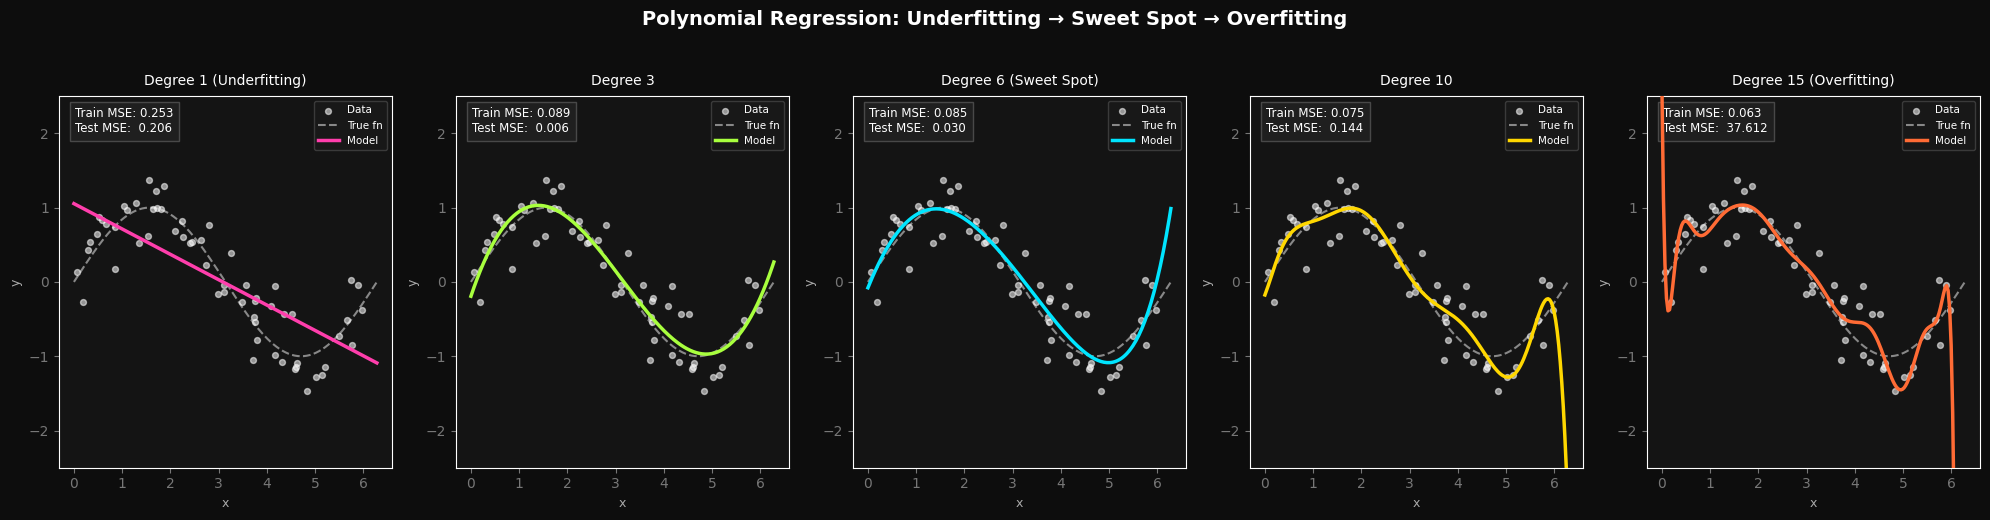

In [10]:
# ─── Section 5: Polynomial Regression — Underfitting / Sweet Spot / Overfitting
plt.style.use('dark_background')

# Non-linear data: y = sin(x) + noise
n5 = 60
x5_train = np.sort(np.random.uniform(0, 2 * np.pi, n5))
y5_train = np.sin(x5_train) + np.random.randn(n5) * 0.35

x5_test = np.linspace(0, 2 * np.pi, 200)
y5_true  = np.sin(x5_test)

degrees = [1, 3, 6, 10, 15]
palette5 = ['#ff3eac', '#a8ff3e', '#00e5ff', '#ffd700', '#ff6b35']
labels5  = ['Degree 1 (Underfitting)', 'Degree 3', 'Degree 6 (Sweet Spot)',
            'Degree 10', 'Degree 15 (Overfitting)']

fig5a, axes5 = plt.subplots(1, len(degrees), figsize=(20, 5), sharey=False)
fig5a.patch.set_facecolor('#0d0d0d')

train_errors, test_errors = [], []

for ax, deg, col, lab in zip(axes5, degrees, palette5, labels5):
    ax.set_facecolor('#141414')

    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(x5_train.reshape(-1, 1), y5_train)

    y5_pred_train = pipe.predict(x5_train.reshape(-1, 1))
    y5_pred_test  = pipe.predict(x5_test.reshape(-1, 1))

    tr_err = mean_squared_error(y5_train, y5_pred_train)
    te_err = mean_squared_error(y5_true, y5_pred_test)
    train_errors.append(tr_err)
    test_errors.append(te_err)

    ax.scatter(x5_train, y5_train, color='white', s=18, alpha=0.55, zorder=3, label='Data')
    ax.plot(x5_test, y5_true, color='#888888', lw=1.5, ls='--', label='True fn', zorder=2)
    ax.plot(x5_test, y5_pred_test, color=col, lw=2.5, label='Model', zorder=4)

    ax.set_title(lab, color='white', fontsize=10, pad=8)
    ax.set_xlabel('x', color='#aaa', fontsize=9)
    ax.set_ylabel('y', color='#aaa', fontsize=9)
    ax.tick_params(colors='#777')
    ax.set_ylim(-2.5, 2.5)
    ax.text(0.05, 0.97, f'Train MSE: {tr_err:.3f}\nTest MSE:  {te_err:.3f}',
            transform=ax.transAxes, color='white', fontsize=8.5,
            va='top', bbox=dict(facecolor='#222', edgecolor='#555', alpha=0.8))
    ax.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=7.5)

fig5a.suptitle('Polynomial Regression: Underfitting → Sweet Spot → Overfitting',
               color='white', fontsize=14, fontweight='bold', y=1.03)
fig5a.tight_layout()
plt.savefig('polynomial_grid.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

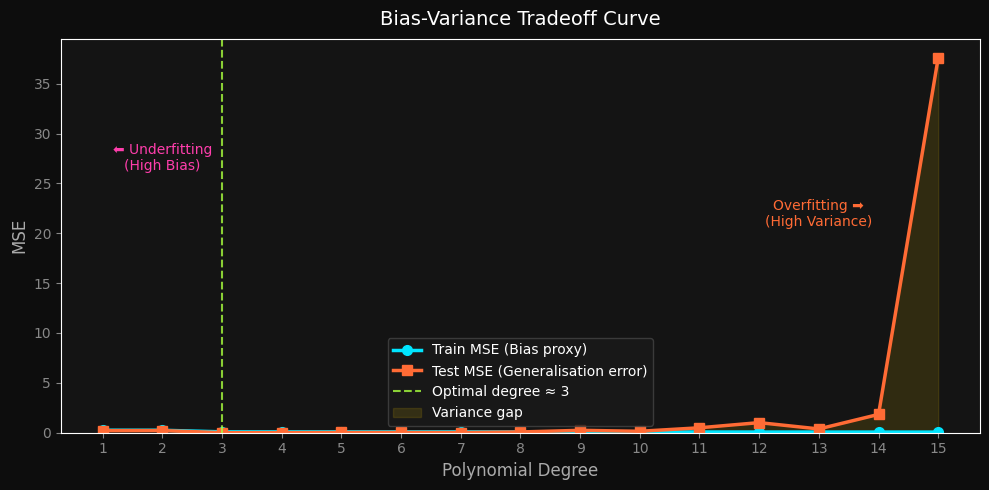

🏆 Optimal polynomial degree: 3 (lowest test MSE = 0.0056)


In [11]:
# ─── Section 5: Bias-Variance Tradeoff Curve ─────────────────────────────────
plt.style.use('dark_background')

all_degrees = list(range(1, 16))
train_mse_list, test_mse_list = [], []

for deg in all_degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])
    pipe.fit(x5_train.reshape(-1, 1), y5_train)
    train_mse_list.append(mean_squared_error(y5_train, pipe.predict(x5_train.reshape(-1, 1))))
    test_mse_list.append(mean_squared_error(y5_true, pipe.predict(x5_test.reshape(-1, 1))))

fig5b, ax5b = plt.subplots(figsize=(10, 5))
fig5b.patch.set_facecolor('#0d0d0d')
ax5b.set_facecolor('#141414')

ax5b.plot(all_degrees, train_mse_list, 'o-', color='#00e5ff', lw=2.5,
          ms=7, label='Train MSE (Bias proxy)')
ax5b.plot(all_degrees, test_mse_list,  's-', color='#ff6b35', lw=2.5,
          ms=7, label='Test MSE (Generalisation error)')

best_deg = all_degrees[np.argmin(test_mse_list)]
ax5b.axvline(best_deg, color='#a8ff3e', lw=1.5, ls='--', alpha=0.8,
             label=f'Optimal degree ≈ {best_deg}')

ax5b.fill_between(all_degrees, train_mse_list, test_mse_list,
                  alpha=0.12, color='#ffd700', label='Variance gap')

ax5b.set_xlabel('Polynomial Degree', color='#aaa', fontsize=12)
ax5b.set_ylabel('MSE', color='#aaa', fontsize=12)
ax5b.set_title('Bias-Variance Tradeoff Curve', color='white', fontsize=14, pad=10)
ax5b.tick_params(colors='#888')
ax5b.set_xticks(all_degrees)
ax5b.set_ylim(bottom=0)
ax5b.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white', fontsize=10)

# Annotate regions
ax5b.annotate('⬅ Underfitting\n(High Bias)', xy=(2, max(test_mse_list) * 0.7),
              color='#ff3eac', fontsize=10, ha='center')
ax5b.annotate('Overfitting ➡\n(High Variance)', xy=(13, max(test_mse_list) * 0.55),
              color='#ff6b35', fontsize=10, ha='center')

fig5b.tight_layout()
plt.savefig('bias_variance.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()

print(f'🏆 Optimal polynomial degree: {best_deg} (lowest test MSE = {min(test_mse_list):.4f})')

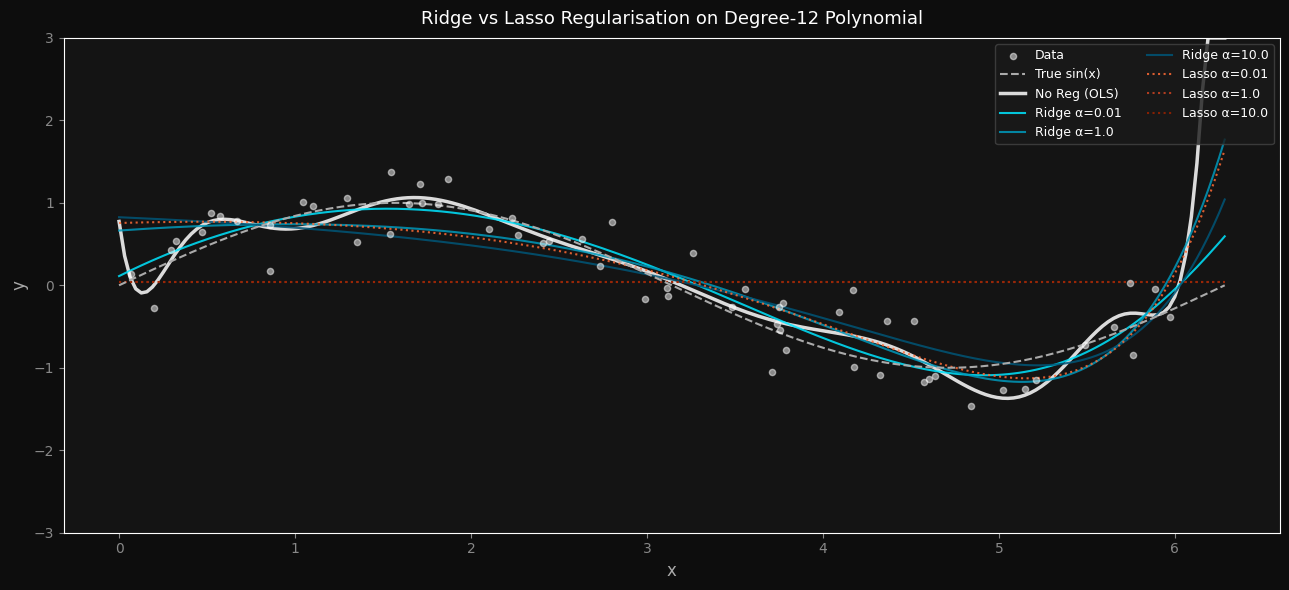

📌 Higher α = stronger regularisation = smoother curves (more bias, less variance)


In [12]:
# ─── Section 5: Ridge vs Lasso on Polynomial Features ────────────────────────
from sklearn.linear_model import Ridge, Lasso
plt.style.use('dark_background')

degree_fixed = 12   # intentionally high to demonstrate regularisation
poly  = PolynomialFeatures(degree=degree_fixed, include_bias=False)
sc5   = StandardScaler()
X5_tr = sc5.fit_transform(poly.fit_transform(x5_train.reshape(-1, 1)))
X5_te = sc5.transform(poly.transform(x5_test.reshape(-1, 1)))

alphas   = [0.01, 1.0, 10.0]
models   = {'No Reg (OLS)': LinearRegression(),
            **{f'Ridge α={a}': Ridge(alpha=a) for a in alphas},
            **{f'Lasso α={a}': Lasso(alpha=a, max_iter=10000) for a in alphas}}

colors_r  = ['#ffffff'] + ['#00e5ff', '#0099bb', '#005577'] + ['#ff6b35', '#cc4422', '#992200']

fig_reg, ax_reg = plt.subplots(figsize=(13, 6))
fig_reg.patch.set_facecolor('#0d0d0d')
ax_reg.set_facecolor('#141414')

ax_reg.scatter(x5_train, y5_train, color='white', s=20, alpha=0.5,
               zorder=5, label='Data')
ax_reg.plot(x5_test, y5_true, color='#aaaaaa', lw=1.5, ls='--',
            label='True sin(x)', zorder=4)

for (name, model), col in zip(models.items(), colors_r):
    model.fit(X5_tr, y5_train)
    y_pred = model.predict(X5_te)
    lw = 2.5 if 'No Reg' in name else 1.5
    ls = '-' if 'Ridge' in name or 'No Reg' in name else ':'
    ax_reg.plot(x5_test, np.clip(y_pred, -3, 3), color=col,
                lw=lw, ls=ls, label=name, alpha=0.85)

ax_reg.set_ylim(-3, 3)
ax_reg.set_xlabel('x', color='#aaa', fontsize=12)
ax_reg.set_ylabel('y', color='#aaa', fontsize=12)
ax_reg.set_title(f'Ridge vs Lasso Regularisation on Degree-{degree_fixed} Polynomial',
                 color='white', fontsize=13, pad=10)
ax_reg.tick_params(colors='#888')
ax_reg.legend(facecolor='#1a1a1a', edgecolor='#444', labelcolor='white',
              fontsize=9, ncol=2, loc='upper right')
fig_reg.tight_layout()
plt.savefig('regularisation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('📌 Higher α = stronger regularisation = smoother curves (more bias, less variance)')

---
# 🎓 Summary

| Topic | Key Takeaway |
|---|---|
| **Simple Linear Regression** | $\hat{y} = \beta_0 + \beta_1 x$; minimise MSE via Gradient Descent |
| **Feature Scaling** | Normalise features to make GD converge faster and stably |
| **Multiple Linear Regression** | Matrix form $\mathbf{\hat{Y}} = \mathbf{X}\boldsymbol{\beta}$; GD scales gracefully |
| **Assumptions** | Linearity, Independence, Homoscedasticity, Normality, No Multicollinearity |
| **Polynomial Regression** | Non-linear patterns with linear model; regularise to prevent overfitting |

---

## Next Steps

- 📖 **Regularisation:** Dive deeper into Ridge, Lasso, and Elastic Net.
- 📖 **Cross-Validation:** Learn `KFold` and `GridSearchCV` for robust model selection.
- 📖 **Generalised Linear Models:** Logistic Regression (binary), Poisson Regression (counts).
- 📖 **Robust Regression:** Huber loss and RANSAC for heavy-tailed noise.